In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#importing data
movies = pd.read_csv('my_movies.csv')

In [ ]:
# one hot encoding
movies_onehot = pd.get_dummies(movies, prefix='', prefix_sep='')


In [ ]:
# Apply Apriori algorithm
from mlxtend.frequent_patterns import apriori, association_rules
frequent_itemsets = apriori(movies_onehot, min_support=0.1, use_colnames=True)


/usr/local/lib/python3.10/dist-packages/mlxtend/frequent_patterns/fpcommon.py:110: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [ ]:
# Generate and filter association rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)
rules_filtered = rules[(rules['antecedents'].apply(len) >= 2) & (rules['consequents'].apply(len) >= 2)]
rules
len(rules_filtered)
rules_filtered

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
103,"(Gladiator, Green Mile)","(LOTR, Sixth Sense)",0.1,0.1,0.1,1.0,10.0,0.09,inf,1.000000
104,"(Gladiator, LOTR)","(Green Mile, Sixth Sense)",0.1,0.2,0.1,1.0,5.0,0.08,inf,0.888889
105,"(Gladiator, Sixth Sense)","(Green Mile, LOTR)",0.1,0.1,0.1,1.0,10.0,0.09,inf,1.000000
106,"(Green Mile, LOTR)","(Gladiator, Sixth Sense)",0.1,0.1,0.1,1.0,10.0,0.09,inf,1.000000
107,"(LOTR, Sixth Sense)","(Gladiator, Green Mile)",0.1,0.1,0.1,1.0,10.0,0.09,inf,1.000000
114,"(Harry Potter1, LOTR2)","(Sixth Sense, LOTR1)",0.1,0.1,0.1,1.0,10.0,0.09,inf,1.000000
115,"(Harry Potter1, Sixth Sense)","(LOTR2, LOTR1)",0.1,0.1,0.1,1.0,10.0,0.09,inf,1.000000
116,"(Harry Potter1, LOTR1)","(Sixth Sense, LOTR2)",0.1,0.1,0.1,1.0,10.0,0.09,inf,1.000000
117,"(Sixth Sense, LOTR2)","(Harry Potter1, LOTR1)",0.1,0.1,0.1,1.0,10.0,0.09,inf,1.000000
118,"(LOTR2, LOTR1)","(Harry Potter1, Sixth Sense)",0.1,0.1,0.1,1.0,10.0,0.09,inf,1.000000


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


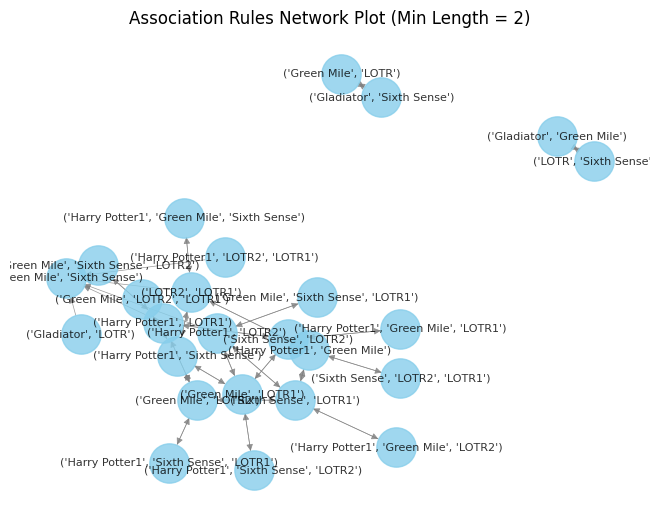

In [ ]:
# Network Plot
import networkx as nx
G = nx.DiGraph()
for i, row in rules_filtered.iterrows():
    G.add_edge(tuple(row['antecedents']), tuple(row['consequents']), weight=row['support'])

pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, font_size=8, font_color='black', node_size=800, node_color='skyblue', edge_color='gray', width=0.5, alpha=0.8, arrowsize=10)
plt.title('Association Rules Network Plot (Min Length = 2)')
plt.show()